# 0. Cargar datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_66638/3745035006.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

In [4]:
print(ventas["Kilos Nc"].isna().sum())
ventas = ventas[ventas["Kilos Nc"].isna()]

9853682


In [5]:
ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 9639035


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado", "Zona", "Distrito",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista",
    # Descuentos
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto",
    "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Distrito,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto,id_descuento_base,ids_descuento_volumen,id_descuento_binario,id_descuento_carta_impacto
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43790,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,2634.000000,2715.0,-3.0,NaN,NaN,NaN,2352.0,NaN,NaN,NaN
2,1227049,HR,37,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,2722.006579,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1174760,CB,32,NaN,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,5171.0,-12.5,NaN,NaN,NaN,2372.0,NaN,NaN,NaN
4,1015869,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,3135.000000,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente                         0
Cod Canal Comercial               199
Cod Consolidado                     0
Zona                           493633
Distrito                       493633
Fecha Factura                       0
Cod SKU                             0
Nombre SKU                          0
Monto Real                          0
Kilo Real                           0
Precio                              6
Precio_Lista                      122
dscto_base                    8384602
dscto_volumen                 8643309
dscto_binario                 7801532
carta_impacto                 9636814
id_descuento_base             8384602
ids_descuento_volumen         8643309
id_descuento_binario          7801532
id_descuento_carta_impacto    9636814
dtype: int64


In [8]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante que no sea de descuentos
ventas = ventas.dropna(subset=[col for col in cols_relevantes_ventas if col not in ["Zona", "Distrito", "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto", "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"]])

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 9639035 filas y 20 columnas antes de filtrar.
El dataframe tiene 9638708 filas y 20 columnas después de filtrar.


## 0.2. Maestro SKUs

In [9]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [10]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruzar bases

In [11]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado", "zona", "distrito",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista",
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto",
    "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,ids_descuento_volumen,id_descuento_binario,id_descuento_carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,NaN,NaN,NaN,2025,1,0.10,False,40.0,True,False
1,43790,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,...,NaN,NaN,NaN,2025,1,3.00,False,4.0,True,False
2,1227049,HR,37,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,...,NaN,NaN,NaN,2025,1,0.38,False,80.0,True,False
3,1174760,CB,32,NaN,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,...,NaN,NaN,NaN,2025,1,0.10,False,24.0,True,False
4,1015869,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,...,NaN,NaN,NaN,2025,1,0.80,False,6.0,True,False


# 2. Análisis de Descuentos

In [12]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

# Filtrar a últimos 6 meses de 2025 según Fecha Factura
mask = (
    (ventas["año_factura"] == 2025) &
    (ventas["mes_factura"].isin(range(6,13)))
)

In [13]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,id_descuento_carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,NaN,2025,1,0.10,False,40.0,True,False,1086.000000,1153.80
1,43790,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,...,NaN,2025,1,3.00,False,4.0,True,False,7902.000000,8145.00
2,1227049,HR,37,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,...,NaN,2025,1,0.38,False,80.0,True,False,1034.362500,1034.36
3,1174760,CB,32,NaN,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,...,NaN,2025,1,0.10,False,24.0,True,False,452.583333,517.10
4,1015869,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,...,NaN,2025,1,0.80,False,6.0,True,False,2508.000000,2585.60


In [14]:
# Agregar columna de descuento aplicado.
# Se considera que una venta calza con un descuento si el descuento porcentual observado
# queda dentro de una tolerancia chica respecto a uno de los descuentos disponibles.
# Prioridad global: carta_impacto -> base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.
# Entre descuentos porcentuales se elige el de menor diferencia absoluta; ante empate,
# la comparación estricta diff < mejor_diff preserva el orden base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.

tolerancia_pct = 1
eps_descuento = 1e-9
tolerancia_precio_carta = 1.0
labels_descuento = np.array([
    "ninguno",
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
], dtype=object)

# Descuento porcentual observado a nivel de precio por unidad.
descuento_pct_observado = ((ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) - 1.0).to_numpy(dtype=np.float32) * np.float32(100.0)

# Se guarda sólo el mejor match para no materializar matrices grandes en memoria.
mejor_diff = np.full(len(ventas), np.inf, dtype=np.float32)
codigos_descuento = np.zeros(len(ventas), dtype=np.int8)
descuento_pct_matcheado = np.zeros(len(ventas), dtype=np.float32)
id_descuento_aplicado = np.full(len(ventas), np.nan, dtype=np.float64)

def _actualizar_mejor_match(candidatos, codigo, ids_candidatos=None):
    candidatos = pd.to_numeric(candidatos, errors="coerce").to_numpy(dtype=np.float32)
    validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
    if not validos.any():
        return

    diff = np.abs(descuento_pct_observado - candidatos)
    mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff)
    mejor_diff[mask] = diff[mask]
    codigos_descuento[mask] = codigo
    descuento_pct_matcheado[mask] = candidatos[mask]
    if ids_candidatos is not None:
        ids_candidatos = pd.to_numeric(ids_candidatos, errors="coerce").to_numpy(dtype=np.float64)
        id_descuento_aplicado[mask] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_base"], 1, ventas["id_descuento_base"])

# dscto_volumen viene serializado como string tipo "[-5.0, -10.0]" en el CSV final.
# ids_descuento_volumen viene serializado como string tipo "[12, 25]" y sigue el mismo orden.
mask_volumen = ventas["dscto_volumen"].notna() & ventas["ids_descuento_volumen"].notna()
if mask_volumen.any():
    volumen_extraido = ventas.loc[mask_volumen, "dscto_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    ids_volumen_extraidos = ventas.loc[mask_volumen, "ids_descuento_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    idx_volumen = np.flatnonzero(mask_volumen.to_numpy())

    for codigo, col in enumerate(volumen_extraido.columns, start=2):
        candidatos = pd.to_numeric(volumen_extraido[col], errors="coerce").to_numpy(dtype=np.float32)
        ids_candidatos = pd.to_numeric(ids_volumen_extraidos[col], errors="coerce").to_numpy(dtype=np.float64)
        validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
        if not validos.any():
            continue

        diff = np.abs(descuento_pct_observado[idx_volumen] - candidatos)
        mejor_diff_local = mejor_diff[idx_volumen]
        mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff_local)
        if mask.any():
            idx_target = idx_volumen[mask]
            mejor_diff[idx_target] = diff[mask]
            codigos_descuento[idx_target] = codigo
            descuento_pct_matcheado[idx_target] = candidatos[mask]
            id_descuento_aplicado[idx_target] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_binario"], 5, ventas["id_descuento_binario"])

# carta_impacto representa un precio objetivo, no un descuento porcentual, y si calza por precio_real
# dentro de la tolerancia definida, pisa cualquier match porcentual previo.
precio_real_array = pd.to_numeric(ventas["precio_real"], errors="coerce").to_numpy(dtype=np.float32)
precio_lista_array = pd.to_numeric(ventas["precio_lista"], errors="coerce").to_numpy(dtype=np.float32)
carta_array = pd.to_numeric(ventas["carta_impacto"], errors="coerce").to_numpy(dtype=np.float32)
carta_ids_array = pd.to_numeric(ventas["id_descuento_carta_impacto"], errors="coerce").to_numpy(dtype=np.float64)
carta_pct_equivalente = np.where(
    (~np.isnan(carta_array)) & (~np.isnan(precio_lista_array)) & (np.abs(precio_lista_array) > eps_descuento),
    ((carta_array / precio_lista_array) - np.float32(1.0)) * np.float32(100.0),
    np.nan,
)
mask_carta = (~np.isnan(carta_array)) & (np.abs(precio_real_array - carta_array) <= tolerancia_precio_carta)
codigos_descuento[mask_carta] = 6
descuento_pct_matcheado[mask_carta] = carta_pct_equivalente[mask_carta]
mejor_diff[mask_carta] = np.abs(descuento_pct_observado[mask_carta] - descuento_pct_matcheado[mask_carta])
id_descuento_aplicado[mask_carta] = carta_ids_array[mask_carta]

ventas["descuento_pct_observado"] = descuento_pct_observado
ventas["descuento_pct_matcheado"] = descuento_pct_matcheado
ventas["diferencia_descuento_pct"] = ventas["descuento_pct_observado"] - ventas["descuento_pct_matcheado"]
ventas["descuento_aplicado"] = pd.Categorical.from_codes(codigos_descuento, categories=labels_descuento)
ventas["id_descuento_aplicado"] = pd.array(id_descuento_aplicado, dtype="Int64")
ventas["calza_con_descuento"] = np.not_equal(codigos_descuento, 0)

print("Distribución descuento_aplicado:")
print(ventas["descuento_aplicado"].value_counts(dropna=False))
print(f"Cobertura de match: {ventas['calza_con_descuento'].mean():.2%}")

cols_muestra = [
    "cod_sku",
    "cod_canal_comercial",
    "cod_consolidado",
    "fecha_factura",
    "precio_por_unidad",
    "precio_lista_por_unidad",
    "descuento_pct_observado",
    "dscto_base",
    "id_descuento_base",
    "dscto_volumen",
    "ids_descuento_volumen",
    "dscto_binario",
    "id_descuento_binario",
    "carta_impacto",
    "id_descuento_carta_impacto",
    "descuento_pct_matcheado",
    "diferencia_descuento_pct",
    "descuento_aplicado",
    "id_descuento_aplicado",
]
ventas.loc[ventas["calza_con_descuento"], cols_muestra].head()

Distribución descuento_aplicado:
descuento_aplicado
ninguno          7240515
binario          1151248
base              918032
volumen_1         214375
volumen_2          82671
volumen_3          29544
carta_impacto       2091
Name: count, dtype: int64
Cobertura de match: 24.88%


,cod_sku,cod_canal_comercial,cod_consolidado,fecha_factura,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado
1,399,HR,55,2025-01-03,7902.000000,8145.00,-2.983425,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,0.016575,base,2352
3,3991,CB,32,2025-01-02,452.583333,517.10,-12.476633,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN,-12.5,0.023367,base,2372
7,6800,CB,54,2025-01-02,5330.050000,5495.00,-3.001820,-3.0,2837.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.001820,base,2837
10,3144,CB,54,2025-01-02,564.250000,581.75,-3.008165,-3.0,1277.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.008165,base,1277
11,3142,CB,54,2025-01-02,564.250000,581.75,-3.008165,-3.0,1262.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.008165,base,1262


In [15]:
# gap/no-gap
ventas['gap'] = ventas['diferencia_descuento_pct'].abs() > 1

In [16]:
ventas["gap"].value_counts()

gap
False    8943030
True      695446
Name: count, dtype: int64

In [17]:
ventas_no_gap = ventas[ventas["gap"]==False]
ventas_no_gap["descuento_aplicado"].value_counts()

descuento_aplicado
ninguno          6545069
binario          1151248
base              918032
volumen_1         214375
volumen_2          82671
volumen_3          29544
carta_impacto       2091
Name: count, dtype: int64

In [18]:
# Calcular el "costo" de cada descuento como la diferencia entre el precio lista y el precio real, multiplicado por la cantidad en unidades vendida.
# Esto sólo para las ventas que calzan con algún descuento, para evitar ruido de errores de medición o casos atípicos sin descuento claro.
ventas["monto_a_precio_lista"] = ventas["precio_lista"] * ventas["kilo_real"]
ventas["costo_descuento"] = ventas["monto_a_precio_lista"] - ventas["monto_real"] #(ventas["precio_lista_por_unidad"] - ventas["precio_por_unidad"]) * ventas["cantidad_unidades"]
#ventas["costo_descuento"] = ventas["costo_descuento"].where(ventas["calza_con_descuento"], 0.0)
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,1153.80,-5.876235,0.0,-5.876235,ninguno,<NA>,False,True,46152.0,2712.0
1,43790,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,...,8145.00,-2.983425,-3.0,0.016575,base,2352,True,False,32580.0,972.0
2,1227049,HR,37,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,...,1034.36,0.000242,0.0,0.000242,ninguno,<NA>,False,False,82748.8,-0.2
3,1174760,CB,32,NaN,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,...,517.10,-12.476633,-12.5,0.023367,base,2372,True,False,12410.4,1548.4
4,1015869,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,...,2585.60,-3.001238,0.0,-3.001238,ninguno,<NA>,False,True,15513.6,465.6


In [19]:
# Forzar categoría de descuento según supuestos
mask_base_forzado =  (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().isin([-3.0, -6.0]))
mask_liq_forzado = (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().le(-40.0))

ventas['descuento_aplicado'] = ventas['descuento_aplicado'].cat.add_categories(["base_forzado", "liquidacion_forzado"])
ventas.loc[mask_base_forzado, "descuento_aplicado"] = "base_forzado"
ventas.loc[mask_liq_forzado, "descuento_aplicado"] = "liquidacion_forzado"
ventas.loc[mask_base_forzado | mask_liq_forzado, "id_descuento_aplicado"] = pd.NA

In [20]:
ventas.to_csv("datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv", index=False)

In [21]:
mask_base_forzado.value_counts()

False    9080490
True      557986
Name: count, dtype: int64

In [22]:
# Armar tabla con monto total vendido y costo por tipo de descuento y graficar como barras.
tabla_descuentos = ventas.groupby("descuento_aplicado").agg(
    monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
    monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
    costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum")
).reset_index()
#tabla_descuentos["costo_total_dscto_v2"] = tabla_descuentos["monto_a_precio_lista"] - tabla_descuentos["monto_total_vendido"]

In [23]:
# Quiero un gráfico de barras con una columna que tenga el monto total si todo se vendía a precio lista y luego una columna por tipo de descuento indicando el costo de ese descuento para finalmente llegar a una columan con el monto real vendido.
monto_a_precio_lista = ventas["monto_a_precio_lista"].sum()
costo_dscto_base = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "base", "costo_total_descuento"].values[0]
costo_dscto_volumen_1 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_1", "costo_total_descuento"].values[0]
costo_dscto_volumen_2 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_2", "costo_total_descuento"].values[0]
costo_dscto_volumen_3 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_3", "costo_total_descuento"].values[0]
costo_dscto_binario = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "binario", "costo_total_descuento"].values[0]
costo_dscto_carta = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "carta_impacto", "costo_total_descuento"].values[0]
costo_dscto_base_forzado = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "base_forzado", "costo_total_descuento"].values[0]
costo_dscto_liquidacion_forzado = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "liquidacion_forzado", "costo_total_descuento"].values[0]
monto_real = ventas["monto_real"].sum()
error = monto_a_precio_lista - (costo_dscto_base + costo_dscto_volumen_1 + costo_dscto_volumen_2 + costo_dscto_volumen_3 + costo_dscto_binario + costo_dscto_carta + costo_dscto_base_forzado+ costo_dscto_liquidacion_forzado + monto_real)

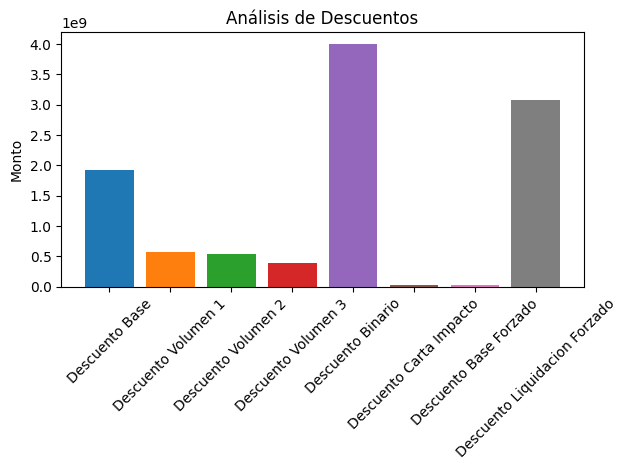

In [24]:


# Graficamos una barra por cada uno de los numeros de arriba
plt.Figure(figsize=(10, 6))
#plt.bar("Monto a Precio Lista", monto_a_precio_lista, label="Precio Lista")
plt.bar("Descuento Base", costo_dscto_base, label="Descuento Base")
plt.bar("Descuento Volumen 1", costo_dscto_volumen_1, label="Descuento Volumen 1")
plt.bar("Descuento Volumen 2", costo_dscto_volumen_2, label="Descuento Volumen 2")
plt.bar("Descuento Volumen 3", costo_dscto_volumen_3, label="Descuento Volumen 3")
plt.bar("Descuento Binario", costo_dscto_binario, label="Descuento Binario")
plt.bar("Descuento Carta Impacto", costo_dscto_carta, label="Descuento Carta Impacto")
plt.bar("Descuento Base Forzado", costo_dscto_carta, label="Descuento Base Forzado")
plt.bar("Descuento Liquidacion Forzado", costo_dscto_liquidacion_forzado, label="Descuento Liquidacion Forzado")
#plt.bar("Monto Real", monto_real, label="Monto Real")
#plt.bar("Error", error, label="Error", color="red")
plt.ylabel("Monto")
plt.title("Análisis de Descuentos")
#plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

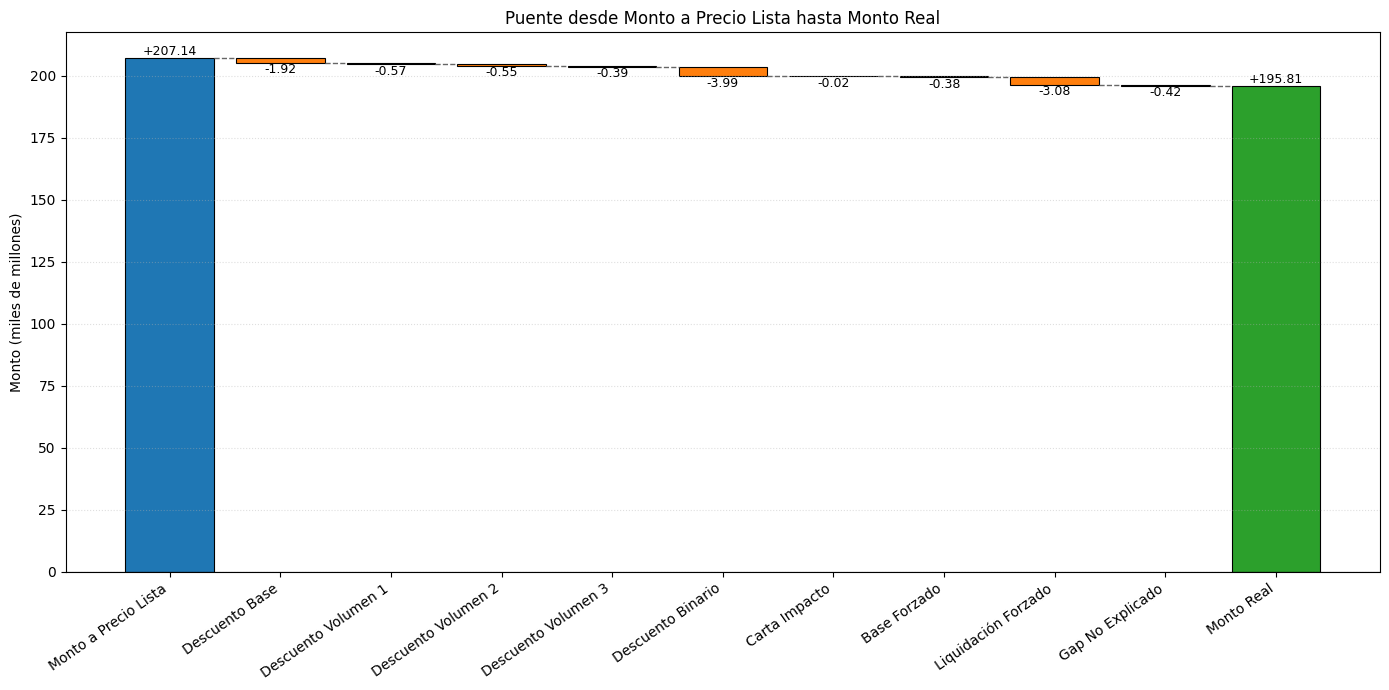

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados,1.090963e+10
2,Gap No Explicado,4.157143e+08
3,Monto Real,1.958115e+11
4,% gap explicado,9.632935e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-1.922581e+09,change
2,Descuento Volumen 1,-5.657882e+08,change
3,Descuento Volumen 2,-5.454265e+08,change
4,Descuento Volumen 3,-3.941829e+08,change
5,Descuento Binario,-3.992977e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Base Forzado,-3.825634e+08,change
8,Liquidación Forzado,-3.084444e+09,change
9,Gap No Explicado,-4.157143e+08,change


In [25]:
# Gráfico tipo cascada: desde monto a precio lista hasta monto real.
# Los descuentos explicados se restan como variaciones negativas y el residuo queda en Gap No Explicado.

categorias_descuento = ["base", "volumen_1", "volumen_2", "volumen_3", "binario", "carta_impacto", "base_forzado", "liquidacion_forzado"]
labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado",
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend((labels_descuento[c], -costos_explicados[c], "change") for c in categorias_descuento)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]
    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running
    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala

colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
ax.bar(x, waterfall_df["height_plot"], bottom=waterfall_df["bottom_plot"], color=colors, edgecolor="black", linewidth=0.8)

# Líneas conectoras entre pasos para reforzar el efecto cascada.
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot([x[i] + 0.4, x[i + 1] - 0.4], [y, y], color="#666666", linestyle="--", linewidth=1)

for i, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        y_text = row["height_plot"]
    else:
        y_text = row["running_plot"]
    va = "bottom" if row["valor"] >= 0 else "top"
    offset = 0.15 if row["valor"] >= 0 else -0.15
    ax.text(
        x[i],
        y_text + offset,
        f"{row['valor_plot']:+.2f}",
        ha="center",
        va=va,
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Puente desde Monto a Precio Lista hasta Monto Real")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})
display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])


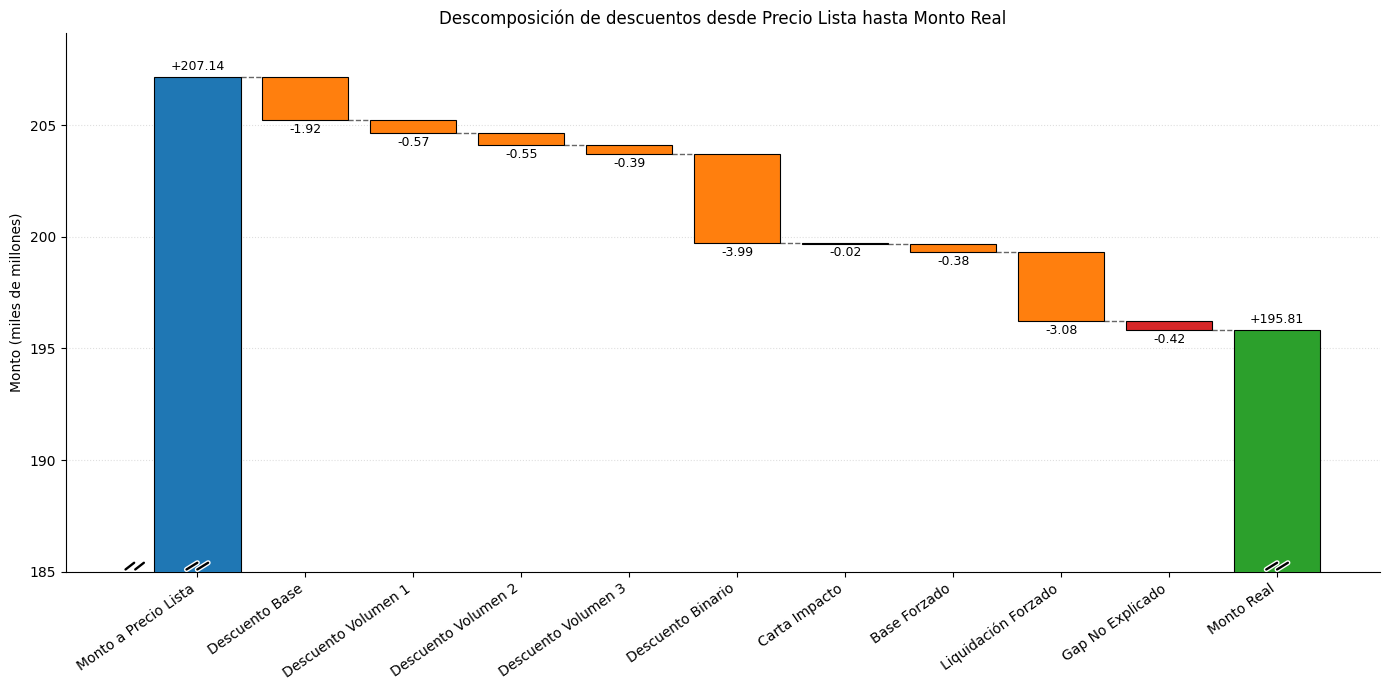

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados,1.090963e+10
2,Gap No Explicado,4.157143e+08
3,Monto Real,1.958115e+11
4,% gap explicado,9.632935e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-1.922581e+09,change
2,Descuento Volumen 1,-5.657882e+08,change
3,Descuento Volumen 2,-5.454265e+08,change
4,Descuento Volumen 3,-3.941829e+08,change
5,Descuento Binario,-3.992977e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Base Forzado,-3.825634e+08,change
8,Liquidación Forzado,-3.084444e+09,change
9,Gap No Explicado,-4.157143e+08,change


In [27]:
import matplotlib.patheffects as pe
# =========================
# CONFIGURACIÓN
# =========================
# Ajusta este valor para definir desde dónde parte visualmente el eje Y.
# Mientras más alto, más "zoom" sobre los descuentos.
Y_FLOOR = 185

# Si quieres que sea automático, puedes poner:
# Y_FLOOR = None


# =========================
# DATOS BASE
# =========================
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "base_forzado",
    "liquidacion_forzado"
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado"
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]

    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running

    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    """
    Dibuja el símbolo // sobre una barra truncada visualmente.
    """
    xc = patch.get_x() + patch.get_width() / 2

    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    """
    Dibuja // sobre el eje Y izquierdo para reforzar la idea de recorte.
    """
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x,
    waterfall_df["height_plot"],
    bottom=waterfall_df["bottom_plot"],
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Líneas conectoras entre pasos
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y],
        color="#666666",
        linestyle="--",
        linewidth=1,
        zorder=2
    )

# =========================
# RANGO VISUAL (RECORTE TIPO THINK-CELL)
# =========================
if Y_FLOOR is None:
    running_max = max(
        waterfall_df["running_plot"].max(),
        waterfall_df["height_plot"].max()
    )
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(
    waterfall_df["top_plot"].max(),
    waterfall_df["running_plot"].max()
)
y_top = visible_max + 2.0

ax.set_ylim(y_floor, y_top)

# Marcar barras truncadas con //
for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

# Marcar también el eje Y
add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"

    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"

    ax.text(
        x[i],
        y_text,
        valor_txt,
        ha="center",
        va=va,
        fontsize=9,
        zorder=10
    )

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")

ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

In [28]:
# Juntar categorías descuento base y base_forzado
ventas["descuento_aplicado"] = ventas["descuento_aplicado"].replace({"base_forzado": "base"})

tabla_descuentos = ventas.groupby("descuento_aplicado").agg(
    monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
    monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
    costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum")
).reset_index()

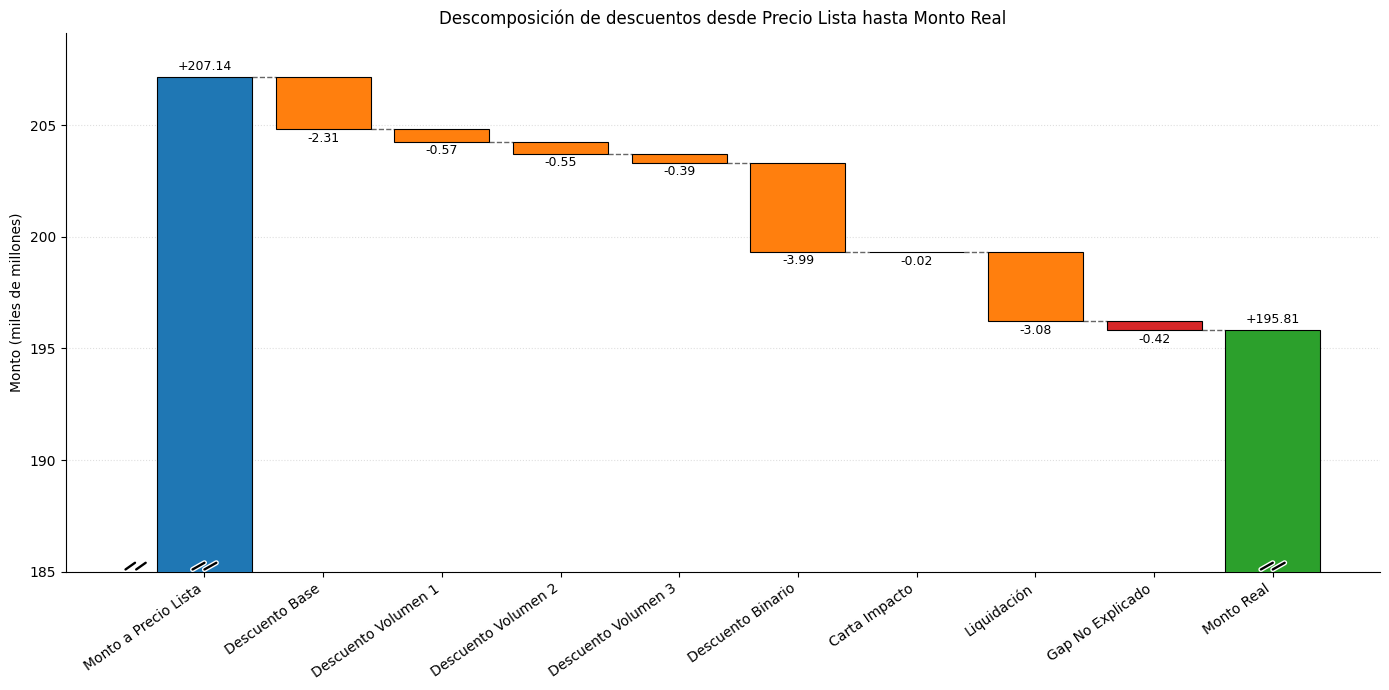

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados,1.090963e+10
2,Gap No Explicado,4.157143e+08
3,Monto Real,1.958115e+11
4,% gap explicado,9.632935e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-2.305145e+09,change
2,Descuento Volumen 1,-5.657882e+08,change
3,Descuento Volumen 2,-5.454265e+08,change
4,Descuento Volumen 3,-3.941829e+08,change
5,Descuento Binario,-3.992977e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Liquidación,-3.084444e+09,change
8,Gap No Explicado,-4.157143e+08,change
9,Monto Real,1.958115e+11,total


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# CONFIGURACIÓN
# =========================
# Ajusta este valor para definir desde dónde parte visualmente el eje Y.
# Mientras más alto, más "zoom" sobre los descuentos.
Y_FLOOR = 185

# Si quieres que sea automático, puedes poner:
# Y_FLOOR = None


# =========================
# DATOS BASE
# =========================
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "liquidacion_forzado"
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "liquidacion_forzado": "Liquidación"
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]

    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running

    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    """
    Dibuja el símbolo // sobre una barra truncada visualmente.
    """
    xc = patch.get_x() + patch.get_width() / 2

    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    """
    Dibuja // sobre el eje Y izquierdo para reforzar la idea de recorte.
    """
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x,
    waterfall_df["height_plot"],
    bottom=waterfall_df["bottom_plot"],
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Líneas conectoras entre pasos
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y],
        color="#666666",
        linestyle="--",
        linewidth=1,
        zorder=2
    )

# =========================
# RANGO VISUAL (RECORTE TIPO THINK-CELL)
# =========================
if Y_FLOOR is None:
    running_max = max(
        waterfall_df["running_plot"].max(),
        waterfall_df["height_plot"].max()
    )
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(
    waterfall_df["top_plot"].max(),
    waterfall_df["running_plot"].max()
)
y_top = visible_max + 2.0

ax.set_ylim(y_floor, y_top)

# Marcar barras truncadas con //
for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

# Marcar también el eje Y
add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"

    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"

    ax.text(
        x[i],
        y_text,
        valor_txt,
        ha="center",
        va=va,
        fontsize=9,
        zorder=10
    )

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")

ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

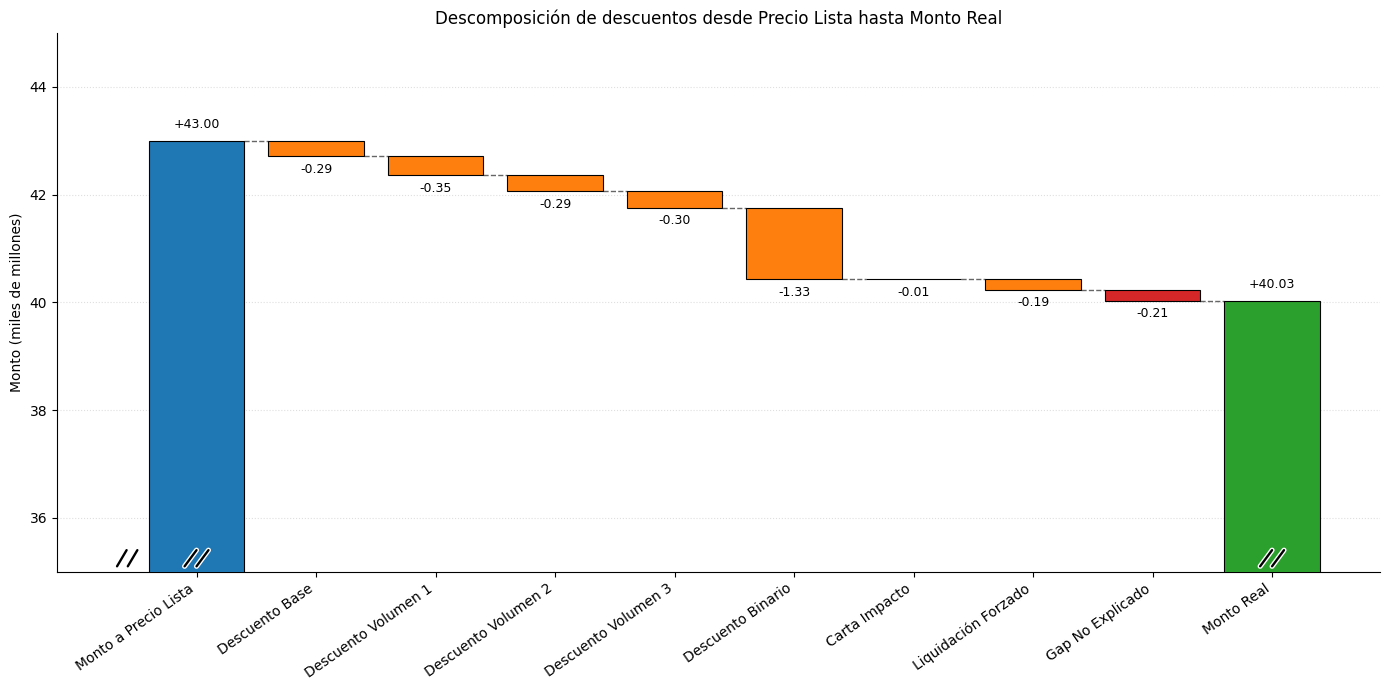

,concepto,valor
0,Monto a Precio Lista,4.300234e+10
1,Descuentos Explicados,2.766258e+09
2,Gap No Explicado,2.108640e+08
3,Monto Real,4.002522e+10
4,% gap explicado,9.291719e-01


,etapa,valor,tipo
0,Monto a Precio Lista,4.300234e+10,total
1,Descuento Base,-2.949927e+08,change
2,Descuento Volumen 1,-3.506539e+08,change
3,Descuento Volumen 2,-2.947843e+08,change
4,Descuento Volumen 3,-3.043833e+08,change
5,Descuento Binario,-1.327082e+09,change
6,Carta Impacto,-5.005349e+06,change
7,Liquidación Forzado,-1.893562e+08,change
8,Gap No Explicado,-2.108640e+08,change
9,Monto Real,4.002522e+10,total


In [30]:
# Filtrar ventas a primeros 3 meses 2026
ventas_filtradas = ventas[
    (ventas["año_factura"] == 2026) &
    (ventas["mes_factura"].isin(range(1, 4)))
]

carroñeros = [
    1070919,
    52847,
    1227734,
    1233882,
    1218124
]

ventas_filtradas = ventas_filtradas[~ventas_filtradas["cod_cliente"].isin(carroñeros)]

# Armar tabla con monto total vendido y costo por tipo de descuento y graficar como barras.
tabla_descuentos_filtrada = ventas_filtradas.groupby("descuento_aplicado").agg(
    monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
    monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
    costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum")
).reset_index()

# Juntar categorías descuento base y base_forzado
tabla_descuentos_filtrada

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# CONFIGURACIÓN
# =========================
# Ajusta este valor para definir desde dónde parte visualmente el eje Y.
# Mientras más alto, más "zoom" sobre los descuentos.
Y_FLOOR = 35

# Si quieres que sea automático, puedes poner:
# Y_FLOOR = None


# =========================
# DATOS BASE
# =========================
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "liquidacion_forzado"
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "liquidacion_forzado": "Liquidación Forzado"
}

costos_explicados = (
    tabla_descuentos_filtrada
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas_filtradas["monto_a_precio_lista"].sum()
monto_real_total = ventas_filtradas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]

    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running

    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    """
    Dibuja el símbolo // sobre una barra truncada visualmente.
    """
    xc = patch.get_x() + patch.get_width() / 2

    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    """
    Dibuja // sobre el eje Y izquierdo para reforzar la idea de recorte.
    """
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x,
    waterfall_df["height_plot"],
    bottom=waterfall_df["bottom_plot"],
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Líneas conectoras entre pasos
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y],
        color="#666666",
        linestyle="--",
        linewidth=1,
        zorder=2
    )

# =========================
# RANGO VISUAL (RECORTE TIPO THINK-CELL)
# =========================
if Y_FLOOR is None:
    running_max = max(
        waterfall_df["running_plot"].max(),
        waterfall_df["height_plot"].max()
    )
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(
    waterfall_df["top_plot"].max(),
    waterfall_df["running_plot"].max()
)
y_top = visible_max + 2.0

ax.set_ylim(y_floor, y_top)

# Marcar barras truncadas con //
for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

# Marcar también el eje Y
add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"

    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"

    ax.text(
        x[i],
        y_text,
        valor_txt,
        ha="center",
        va=va,
        fontsize=9,
        zorder=10
    )

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")

ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

In [31]:
ventas["descuento_pct_observado_redondeado"] =  ventas["descuento_pct_observado"].round()
lista = ventas[((ventas["gap"]==True) & (ventas["descuento_aplicado"]!="base_forzado") & (ventas["descuento_aplicado"]!="liquidacion_forzado"))].groupby("descuento_pct_observado_redondeado")["costo_descuento"].sum().sort_values(ascending=False)
print(lista.to_string())

descuento_pct_observado_redondeado
-3.0      3.686919e+08
-15.0     1.588191e+08
-10.0     8.644212e+07
-20.0     3.039590e+07
-17.0     2.511653e+07
-25.0     2.500605e+07
-18.0     1.870743e+07
-30.0     1.607746e+07
-6.0      1.387152e+07
-19.0     1.057023e+07
-12.0     1.034280e+07
-9.0      1.028263e+07
-13.0     9.566794e+06
-11.0     7.243238e+06
-8.0      3.303150e+06
-7.0      3.261808e+06
-5.0      2.835920e+06
-4.0      2.576528e+06
-14.0     2.519511e+06
-35.0     2.332237e+06
-16.0     1.528530e+06
-26.0     1.109108e+06
-33.0     1.044035e+06
-27.0     1.008424e+06
-24.0     9.352760e+05
-23.0     8.257741e+05
-29.0     7.524448e+05
-22.0     7.032658e+05
-36.0     6.698456e+05
-32.0     6.619072e+05
-21.0     6.039176e+05
-34.0     3.545996e+05
-2.0      2.521934e+05
-1.0      3.232758e+04
-28.0     2.186800e+04
-38.0     1.055740e+04
-39.0     1.170000e+02
-37.0    -4.000000e+00
 23.0    -2.424250e+03
 46.0    -2.834600e+03
 37.0    -3.603000e+03
 104.0   -3.764000e+03

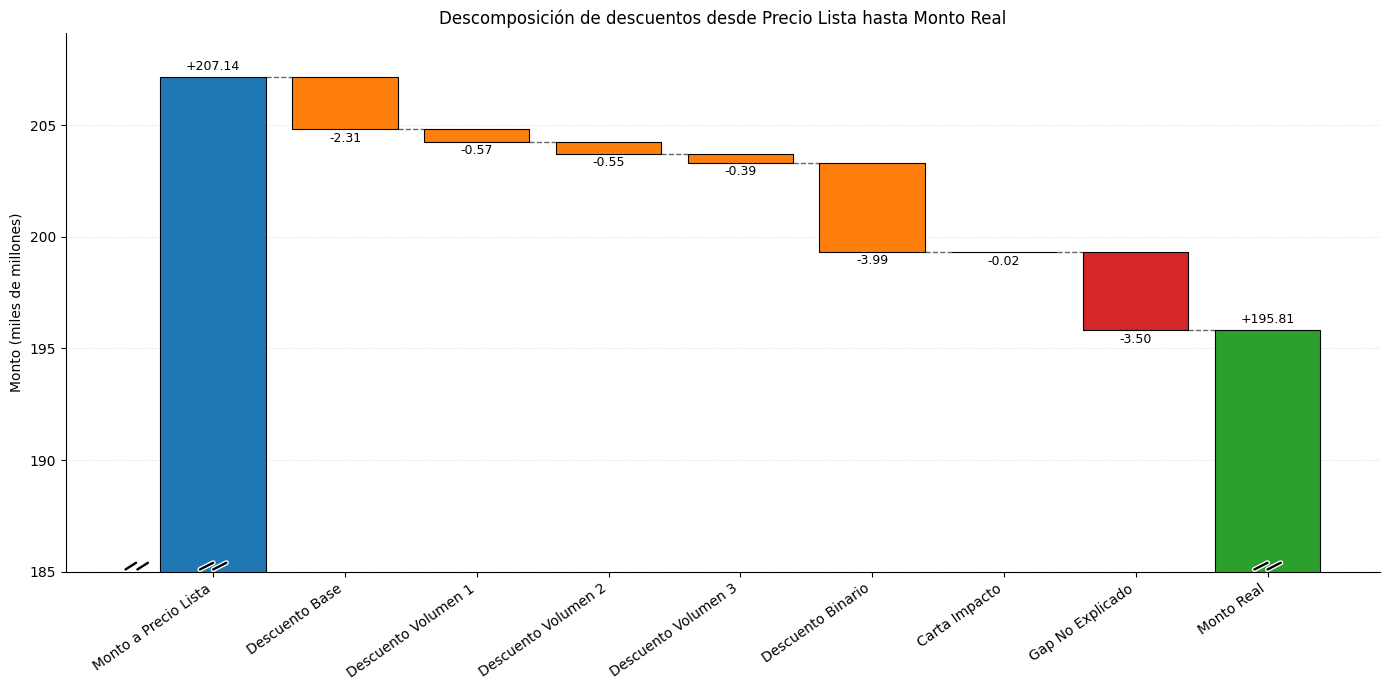

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados (sin forzados),7.825188e+09
2,Gap No Explicado (incluye forzados),3.500158e+09
3,Monto Real,1.958115e+11
4,% gap explicado,6.909447e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-2.305145e+09,change
2,Descuento Volumen 1,-5.657882e+08,change
3,Descuento Volumen 2,-5.454265e+08,change
4,Descuento Volumen 3,-3.941829e+08,change
5,Descuento Binario,-3.992977e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Gap No Explicado,-3.500158e+09,change
8,Monto Real,1.958115e+11,total


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# CONFIGURACIÓN
# =========================
Y_FLOOR = 185

# =========================
# DATOS BASE
# =========================
# Solo las categorías que se muestran como pasos explícitos (sin forzados)
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()

# El gap ahora incluye los forzados implícitamente
gap_no_explicado = gap_total - descuentos_explicados_total

# =========================
# CONSTRUCCIÓN DEL WATERFALL
# =========================
waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]
    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running
    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    xc = patch.get_x() + patch.get_width() / 2
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black", lw=lw, solid_capstyle="round",
            clip_on=False, zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black", lw=lw, solid_capstyle="round",
            clip_on=False, zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x, waterfall_df["height_plot"], bottom=waterfall_df["bottom_plot"],
    width=bar_width, color=colors, edgecolor="black", linewidth=0.8, zorder=3
)

for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y], color="#666666", linestyle="--", linewidth=1, zorder=2
    )

# =========================
# RANGO VISUAL
# =========================
if Y_FLOOR is None:
    running_max = max(waterfall_df["running_plot"].max(), waterfall_df["height_plot"].max())
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(waterfall_df["top_plot"].max(), waterfall_df["running_plot"].max())
y_top = visible_max + 2.0
ax.set_ylim(y_floor, y_top)

for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"
    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"
    ax.text(x[i], y_text, valor_txt, ha="center", va=va, fontsize=9, zorder=10)

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados (sin forzados)",
        "Gap No Explicado (incluye forzados)",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

# Validación

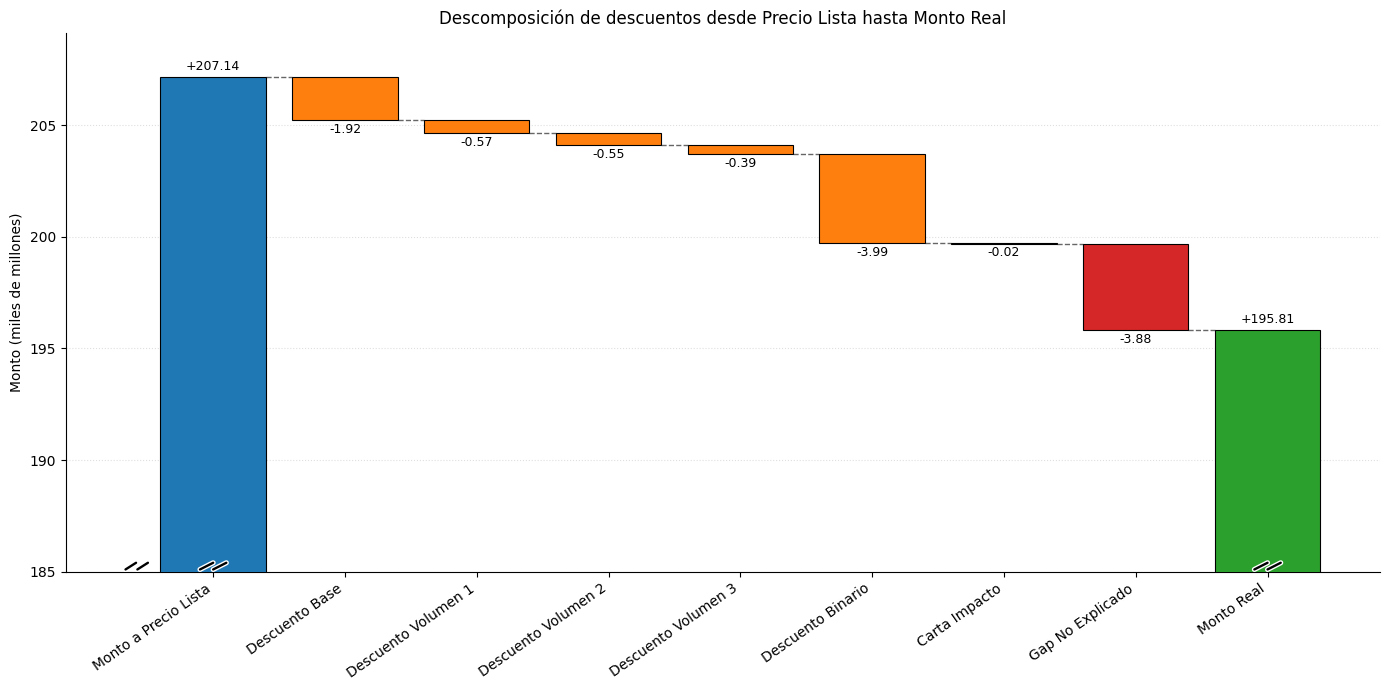

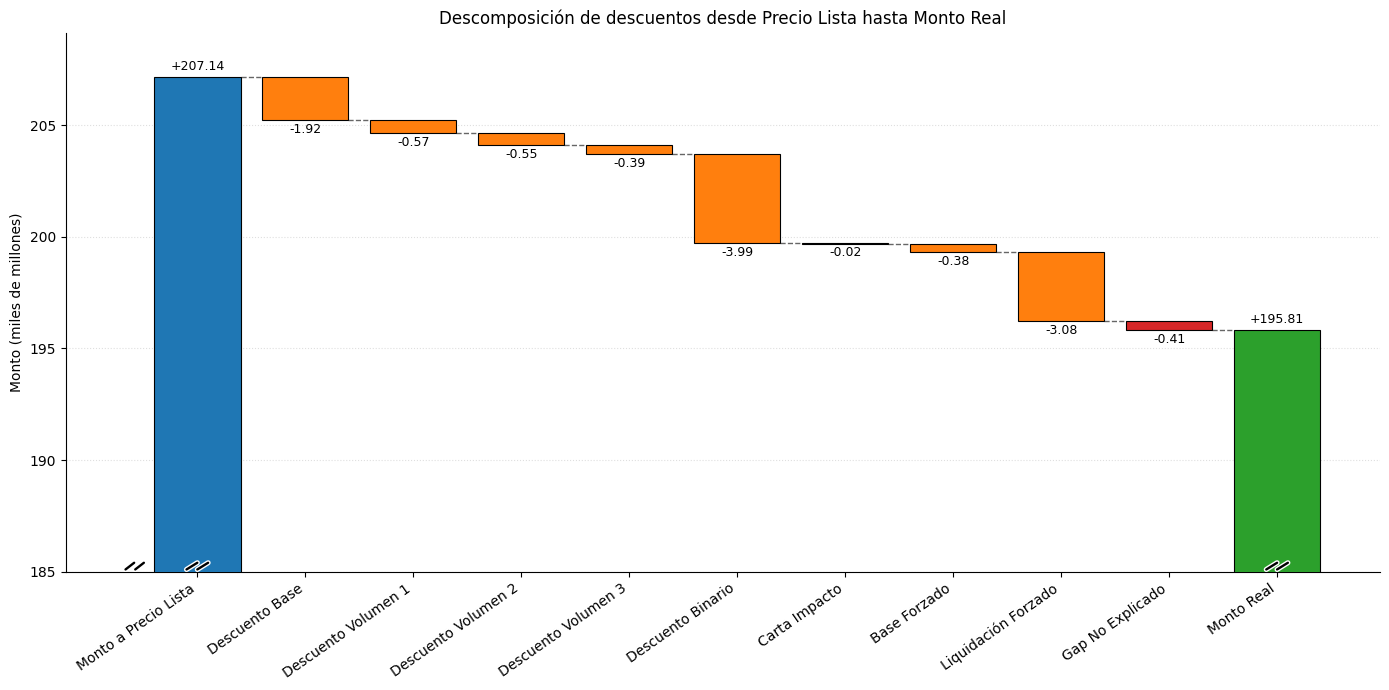


| % DSCTO OBSERVADO |         "COSTO" |
| ---------------------------------: | ------------: |
|                              -15.0 |  158 M |
|                              -10.0 |  85,9 M |
|                              -20.0 |  30,2 M |
|                              -17.0 |  25,1 M |
|                              -25.0 |  25,0 M |
|                              -18.0 |  18,7 M |
|                              -30.0 |  15,8 M |
|                              -19.0 |  10,5 M |
|                              -12.0 |  10,3 M |
|                               -9.0 |  10,2 M |
|                              -13.0 |  9,5 M |

